In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import mlflow
import mlflow.pytorch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

print("PyTorch:", torch.__version__)
print("MLflow:", mlflow.__version__)
print("CUDA available:", torch.cuda.is_available())


c:\Users\G689507\ml-engineering-miniproject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.13.0+cpu
MLflow: 3.15.1
CUDA available: False


In [2]:
SEED = 42

# CPU-friendly settings
IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_EPOCHS = 12

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

VALIDATION_SIZE = 0.20
EARLY_STOPPING_PATIENCE = 3

PROJECT_ROOT = Path("..")

MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "manifest.csv"

MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "casting_cnn_best.pth"

# Local MLflow tracking by default.
# For a shared MLflow server, set the environment variable:
# MLFLOW_TRACKING_URI=http://<server>:5000
MLFLOW_TRACKING_URI = os.getenv(
    "MLFLOW_TRACKING_URI",
    f"file:{(PROJECT_ROOT / 'mlruns').resolve()}"
)

MLFLOW_EXPERIMENT = "casting-quality-cnn"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)
print("MLflow tracking URI:", MLFLOW_TRACKING_URI)


Device: cpu
Image size: 128
Batch size: 32
Epochs: 12
MLflow tracking URI: file:C:\Users\G689507\ml-engineering-miniproject\mlruns


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print("Seed:", SEED)


Seed: 42


In [4]:
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Manifest not found: {MANIFEST_PATH}"
    )

manifest = pd.read_csv(MANIFEST_PATH)

print("Total records:", len(manifest))
print("Columns:", manifest.columns.tolist())

manifest.head()


Total records: 7284
Columns: ['filepath', 'filename', 'split', 'label_name', 'extension', 'file_size_bytes', 'valid_extension', 'non_empty', 'is_readable', 'width', 'height', 'mode', 'file_hash', 'expected_mode', 'is_duplicate', 'is_valid', 'label', 'processed_filepath']


,filepath,filename,split,label_name,extension,file_size_bytes,valid_extension,non_empty,is_readable,width,height,mode,file_hash,expected_mode,is_duplicate,is_valid,label,processed_filepath
0,..\data\raw\test\def_front\cast_def_0_1059.jpeg,cast_def_0_1059.jpeg,test,def_front,.jpeg,10701,True,True,True,300,300,RGB,4e26d6cf05102659baa357b0405d3b97,False,False,True,1,..\data\processed\test\def_front\cast_def_0_10...
1,..\data\raw\test\def_front\cast_def_0_1063.jpeg,cast_def_0_1063.jpeg,test,def_front,.jpeg,9656,True,True,True,300,300,RGB,110f4382c2e4897c5ef7405e15de1946,False,False,True,1,..\data\processed\test\def_front\cast_def_0_10...
2,..\data\raw\test\def_front\cast_def_0_108.jpeg,cast_def_0_108.jpeg,test,def_front,.jpeg,11100,True,True,True,300,300,RGB,d8700301b355952e83eb3620218b0652,False,False,True,1,..\data\processed\test\def_front\cast_def_0_10...
3,..\data\raw\test\def_front\cast_def_0_1096.jpeg,cast_def_0_1096.jpeg,test,def_front,.jpeg,9797,True,True,True,300,300,RGB,695f2a02f07c7f6831f3818bca2e7909,False,False,True,1,..\data\processed\test\def_front\cast_def_0_10...
4,..\data\raw\test\def_front\cast_def_0_112.jpeg,cast_def_0_112.jpeg,test,def_front,.jpeg,11642,True,True,True,300,300,RGB,b22cbc17c6f36f3cb9192ea01e23c08b,False,False,True,1,..\data\processed\test\def_front\cast_def_0_11...


In [5]:
required_columns = [
    "split",
    "label_name",
    "label",
    "processed_filepath"
]

missing = [
    col for col in required_columns
    if col not in manifest.columns
]

if missing:
    raise ValueError(f"Missing columns: {missing}")

print("Class distribution:")
print(manifest["label_name"].value_counts())

print("\nSplit distribution:")
print(manifest["split"].value_counts())


Class distribution:
label_name
def_front    4211
ok_front     3073
Name: count, dtype: int64

Split distribution:
split
train    6569
test      715
Name: count, dtype: int64


In [6]:
train_full = manifest[
    manifest["split"].astype(str).str.lower() == "train"
].copy()

test_df = manifest[
    manifest["split"].astype(str).str.lower() == "test"
].copy()

if train_full.empty or test_df.empty:
    raise ValueError(
        "Train/test split is empty. Check the 'split' column in manifest.csv."
    )

train_df, val_df = train_test_split(
    train_full,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=train_full["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 5255
Validation: 1314
Test: 715


In [7]:
class CastingDataset(Dataset):
    def __init__(self, dataframe, image_size=128, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        image_path = Path(row["processed_filepath"])
        if not image_path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")

        label = float(row["label"])

        image = Image.open(image_path).convert("L")
        image = image.resize(
            (self.image_size, self.image_size),
            Image.Resampling.BILINEAR
        )

        image = np.asarray(image, dtype=np.float32)

        # Lightweight augmentation for training only.
        if self.augment and random.random() < 0.5:
            image = np.fliplr(image).copy()

        image = image / 255.0
        image = (image - 0.5) / 0.5

        image = np.expand_dims(image, axis=0)
        image = torch.from_numpy(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label


In [8]:
train_dataset = CastingDataset(
    train_df, IMAGE_SIZE, augment=True
)

val_dataset = CastingDataset(
    val_df, IMAGE_SIZE, augment=False
)

test_dataset = CastingDataset(
    test_df, IMAGE_SIZE, augment=False
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


Train: 5255
Validation: 1314
Test: 715


In [9]:
NUM_WORKERS = 0

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available()
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs
)

print("DataLoaders ready.")


DataLoaders ready.


In [10]:
import time

start = time.time()
images, labels = next(iter(train_loader))
elapsed = time.time() - start

print("Batch shape:", images.shape)
print(f"Time to load first batch: {elapsed:.2f} seconds")


Batch shape: torch.Size([32, 1, 128, 128])
Time to load first batch: 0.10 seconds


In [11]:
class CastingCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # 128 -> 64
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 64 -> 32
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 32 -> 16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 16 -> 16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)


In [12]:
model = CastingCNN().to(DEVICE)

total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(model)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


CastingCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(1

In [13]:
class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

if 0 not in class_counts.index or 1 not in class_counts.index:
    raise ValueError(
        "Binary labels 0 and 1 are required for this CNN."
    )

negative_count = class_counts[0]
positive_count = class_counts[1]

pos_weight = negative_count / positive_count

print("OK:", negative_count)
print("Defective:", positive_count)
print("Positive class weight:", pos_weight)


OK: 2249
Defective: 3006
Positive class weight: 0.7481703260146374


In [14]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        pos_weight,
        dtype=torch.float32,
        device=DEVICE
    )
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

print("Training configuration ready.")


Training configuration ready.


In [15]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = (torch.sigmoid(outputs) >= 0.5)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


In [16]:
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5)

            all_labels.extend(labels.cpu().numpy().astype(int))
            all_predictions.extend(predictions.cpu().numpy().astype(int))
            all_probabilities.extend(probabilities.cpu().numpy())

    loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)
    recall = recall_score(all_labels, all_predictions, zero_division=0)

    return loss, accuracy, f1, recall


In [17]:
# MLflow setup

import mlflow
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

MLFLOW_DB = PROJECT_ROOT / "mlflow.db"

MLFLOW_TRACKING_URI = (
    f"sqlite:///{MLFLOW_DB.as_posix()}"
)

MLFLOW_EXPERIMENT = "casting-quality-cnn"

mlflow.set_tracking_uri(
    MLFLOW_TRACKING_URI
)

mlflow.set_experiment(
    MLFLOW_EXPERIMENT
)

print(
    "MLflow tracking URI:",
    mlflow.get_tracking_uri()
)

print(
    "MLflow experiment:",
    MLFLOW_EXPERIMENT
)

2026/08/15 11:13:48 INFO mlflow.tracking.fluent: Experiment with name 'casting-quality-cnn' does not exist. Creating a new experiment.


MLflow tracking URI: sqlite:///C:/Users/G689507/ml-engineering-miniproject/mlflow.db
MLflow experiment: casting-quality-cnn


In [18]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "val_f1": [],
    "val_recall": []
}

best_val_loss = float("inf")
patience_counter = 0

with mlflow.start_run(run_name="pytorch-cnn-casting") as run:

    # Parameters
    mlflow.log_params({
        "model": "CastingCNN",
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs_requested": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "validation_size": VALIDATION_SIZE,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "optimizer": "AdamW",
        "loss": "BCEWithLogitsLoss",
        "pos_weight": float(pos_weight),
        "device": str(DEVICE),
        "seed": SEED
    })

    print("MLflow Run ID:", run.info.run_id)
    print("Starting training...\n")

    for epoch in range(NUM_EPOCHS):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_acc, val_f1, val_recall = evaluate(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["val_recall"].append(val_recall)

        current_lr = optimizer.param_groups[0]["lr"]

        mlflow.log_metrics({
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "val_f1": val_f1,
            "val_recall": val_recall,
            "learning_rate": current_lr
        }, step=epoch + 1)

        print(
            f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Val Recall: {val_recall:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0

            torch.save(model.state_dict(), BEST_MODEL_PATH)

            print("  ✓ Best model saved")

        else:
            patience_counter += 1

            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print("\nEarly stopping.")
                break

    # Save history and artifacts
    history_df = pd.DataFrame(history)
    history_path = REPORT_DIR / "training_history.csv"
    history_df.to_csv(history_path, index=False)

    mlflow.log_artifact(str(history_path), artifact_path="training")

    # Log final validation metrics
    mlflow.log_metrics({
        "best_val_loss": float(best_val_loss)
    })

   

MLflow Run ID: b074a789a47b4643941e30bf8aeca9d7
Starting training...

Epoch 01/12 | Train Loss: 0.2961 | Train Acc: 0.8729 | Val Loss: 0.4047 | Val Acc: 0.7861 | Val F1: 0.7706 | Val Recall: 0.6277
  ✓ Best model saved
Epoch 02/12 | Train Loss: 0.1535 | Train Acc: 0.9425 | Val Loss: 0.2671 | Val Acc: 0.8516 | Val F1: 0.8510 | Val Recall: 0.7407
  ✓ Best model saved
Epoch 03/12 | Train Loss: 0.1126 | Train Acc: 0.9570 | Val Loss: 0.0760 | Val Acc: 0.9764 | Val F1: 0.9790 | Val Recall: 0.9588
  ✓ Best model saved
Epoch 04/12 | Train Loss: 0.0825 | Train Acc: 0.9686 | Val Loss: 0.0681 | Val Acc: 0.9650 | Val F1: 0.9684 | Val Recall: 0.9388
  ✓ Best model saved
Epoch 05/12 | Train Loss: 0.0664 | Train Acc: 0.9762 | Val Loss: 0.0837 | Val Acc: 0.9589 | Val F1: 0.9628 | Val Recall: 0.9282
Epoch 06/12 | Train Loss: 0.0530 | Train Acc: 0.9840 | Val Loss: 0.0770 | Val Acc: 0.9521 | Val F1: 0.9563 | Val Recall: 0.9162
Epoch 07/12 | Train Loss: 0.0403 | Train Acc: 0.9878 | Val Loss: 0.0908 | Val 

In [19]:
# Load the best checkpoint saved during training
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)
model.eval()

print("Best model loaded successfully.")


Best model loaded successfully.


In [20]:
from mlflow.models import infer_signature

example_images, _ = next(iter(test_loader))
example_input = example_images[:1].to(DEVICE)

with torch.no_grad():
    example_output = model(example_input)

signature = infer_signature(
    example_input.cpu().numpy(),
    example_output.cpu().numpy()
)

mlflow.pytorch.log_model(
    model,
    name="model",
    signature=signature,
    input_example=example_input.cpu().numpy()
)

W0815 11:19:39.594000 26672 Lib\site-packages\torch\_export\non_strict_utils.py:656] dimension inputs['x'].shape[0] 0/1 specialized; Dim.AUTO was specified along with a sample input with hint = 1.


In [21]:
def get_predictions(model, loader):
    model.eval()

    labels_all = []
    predictions_all = []
    probabilities_all = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)

            outputs = model(images)

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5)

            labels_all.extend(labels.numpy().astype(int))
            predictions_all.extend(predictions.cpu().numpy().astype(int))
            probabilities_all.extend(probabilities.cpu().numpy())

    return (
        np.array(labels_all),
        np.array(predictions_all),
        np.array(probabilities_all)
    )

y_true, y_pred, y_probability = get_predictions(
    model,
    test_loader
)

print("Test samples:", len(y_true))


Test samples: 715


In [22]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_true, y_probability)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results


,Metric,Value
0,Accuracy,0.972028
1,Precision,0.997701
2,Recall,0.958057
3,F1 Score,0.977477
4,ROC AUC,0.997194


In [23]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["OK", "Defective"],
        zero_division=0
    )
)


              precision    recall  f1-score   support

          OK       0.93      1.00      0.96       262
   Defective       1.00      0.96      0.98       453

    accuracy                           0.97       715
   macro avg       0.96      0.98      0.97       715
weighted avg       0.97      0.97      0.97       715



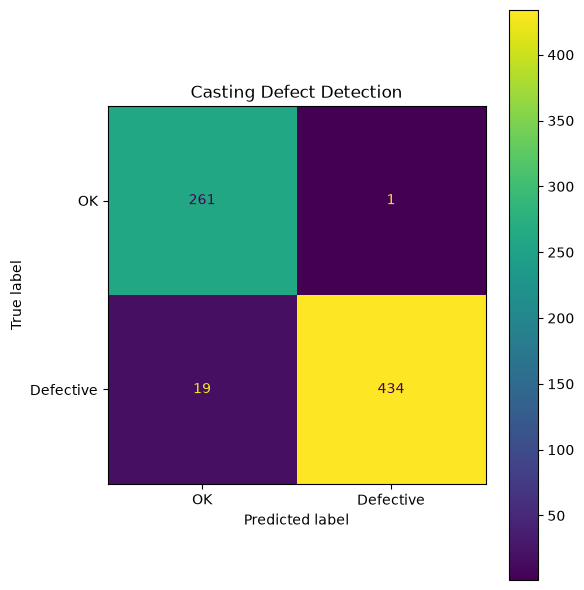

In [24]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["OK", "Defective"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, values_format="d")
ax.set_title("Casting Defect Detection")

plt.tight_layout()

cm_path = FIGURE_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()


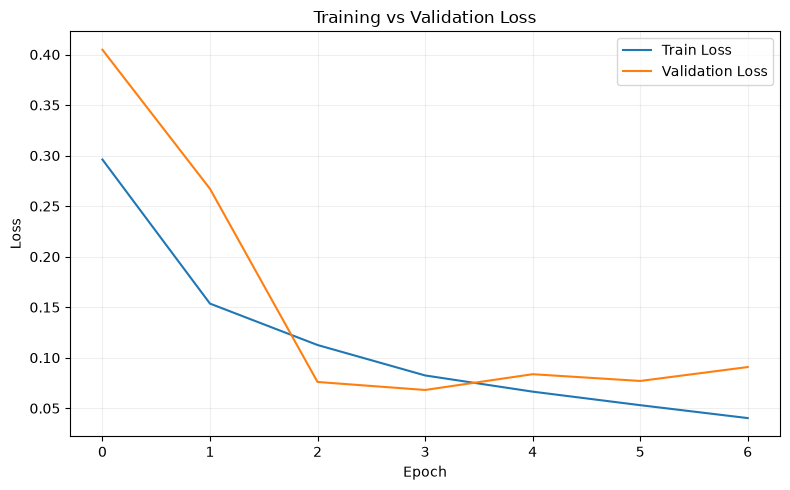

In [25]:
history_df = pd.DataFrame(history)

loss_path = FIGURE_DIR / "training_loss.png"

plt.figure(figsize=(8, 5))
plt.plot(history_df["train_loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(loss_path, dpi=150)
plt.show()


In [26]:
metrics_path = REPORT_DIR / "cnn_test_metrics.csv"
results.to_csv(metrics_path, index=False)

# Log final test results to a separate MLflow run so that
# test evaluation is recorded explicitly.
with mlflow.start_run(run_name="pytorch-cnn-casting-test") as test_run:

    mlflow.log_metrics({
        "test_accuracy": float(accuracy),
        "test_precision": float(precision),
        "test_recall": float(recall),
        "test_f1": float(f1),
        "test_roc_auc": float(roc_auc)
    })

    mlflow.log_artifact(
        str(metrics_path),
        artifact_path="test"
    )

    mlflow.log_artifact(
        str(cm_path),
        artifact_path="test"
    )

    mlflow.log_artifact(
        str(loss_path),
        artifact_path="training"
    )

    print("Test MLflow Run ID:", test_run.info.run_id)

print("=" * 50)
print("CNN TRAINING COMPLETE")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

print("\nModel:", BEST_MODEL_PATH)


Test MLflow Run ID: c8f12e5094344024b037a899557d3f36
CNN TRAINING COMPLETE
Accuracy : 0.9720
Precision: 0.9977
Recall   : 0.9581
F1 Score : 0.9775
ROC AUC  : 0.9972

Model: ..\models\casting_cnn_best.pth
